#  Model Training for Customer Review Sentiment Analysis

This notebook trains and compares multiple baseline NLP models for **3-class sentiment classification**
using the cleaned dataset created in Notebook 1.

## Models compared
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM

## Evaluation focus
Because the classes are imbalanced, we do **not** rely on accuracy alone.

We compare models using:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1

We also inspect:
- Confusion matrices
- Classification reports
- Example predictions

## Outputs
This notebook will:
- train and compare baseline models
- select the best model by **macro F1**
- save the best fitted pipeline
- save label mapping metadata
- export a model comparison table

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
# -----------------------------
# Flexible path detection
# -----------------------------
possible_input_paths = [
    Path("../data/processed/cleaned_reviews.csv"),
    Path("data/processed/cleaned_reviews.csv"),
    Path("/mnt/data/cleaned_reviews.csv"),
]

INPUT_PATH = None
for path in possible_input_paths:
    if path.exists():
        INPUT_PATH = path
        break

if INPUT_PATH is None:
    raise FileNotFoundError(
        "Could not find cleaned_reviews.csv. Run Notebook 1 first, "
        "or place the cleaned dataset in data/processed/cleaned_reviews.csv."
    )

MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs/reports")
FIGURE_DIR = Path("../outputs/figures")

# Fallbacks for environments where notebook sits outside project root
if not MODEL_DIR.parent.exists():
    MODEL_DIR = Path("models")
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("outputs/reports")
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path("outputs/figures")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Input path:", INPUT_PATH)
print("Model directory:", MODEL_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("Figure directory:", FIGURE_DIR.resolve())

Input path: ..\data\processed\cleaned_reviews.csv
Model directory: C:\Users\Owen\Documents\Hertsfordshire\Projects\models
Output directory: C:\Users\Owen\Documents\Hertsfordshire\Projects\customer-review\outputs\reports
Figure directory: C:\Users\Owen\Documents\Hertsfordshire\Projects\customer-review\outputs\figures


In [3]:
df = pd.read_csv(INPUT_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (22635, 15)

Columns:
['clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name', 'full_review', 'sentiment', 'clean_review', 'review_length_words', 'review_length_chars']


,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,full_review,sentiment,clean_review,review_length_words,review_length_chars
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and comf...,positive,absolutely wonderful silky and sexy and comfor...,7,51
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happene...,positive,love this dress it's sooo pretty i happened to...,62,289
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes ...,neutral,some major design flaws i had such high hopes ...,101,509
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"My favorite buy! I love, love, love this jumps...",positive,my favorite buy i love love love this jumpsuit...,25,132
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt This shirt is very flattering...,positive,flattering shirt this shirt is very flattering...,38,204


## Validate required columns

Notebook 1 should have produced:
- `clean_review`
- `sentiment`

If those columns are missing, go back and run Notebook 1 first.

In [4]:
required_cols = ["clean_review", "sentiment"]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.dropna(subset=required_cols).copy()
df["clean_review"] = df["clean_review"].astype(str).str.strip()
df = df[df["clean_review"] != ""].copy()

print("Shape after validation:", df.shape)
df[["clean_review", "sentiment"]].head()

Shape after validation: (22635, 15)


,clean_review,sentiment
0,absolutely wonderful silky and sexy and comfor...,positive
1,love this dress it's sooo pretty i happened to...,positive
2,some major design flaws i had such high hopes ...,neutral
3,my favorite buy i love love love this jumpsuit...,positive
4,flattering shirt this shirt is very flattering...,positive


## Quick class check

In [5]:
class_counts = df["sentiment"].value_counts()
class_props = df["sentiment"].value_counts(normalize=True).round(4)

print("Class counts:")
print(class_counts)

print("\nClass proportions:")
print(class_props)

Class counts:
sentiment
positive    17442
neutral      2823
negative     2370
Name: count, dtype: int64

Class proportions:
sentiment
positive    0.7706
neutral     0.1247
negative    0.1047
Name: proportion, dtype: float64


## Train/test split

We use a stratified split so class proportions remain similar in train and test sets.

In [6]:
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set size: 18108
Test set size: 4527

Train class distribution:
sentiment
positive    0.7706
neutral     0.1247
negative    0.1047
Name: proportion, dtype: float64

Test class distribution:
sentiment
positive    0.7705
neutral     0.1248
negative    0.1047
Name: proportion, dtype: float64


## Define model pipelines

All models use TF-IDF vectorization, then a classifier.

### Design choices
- `ngram_range=(1, 2)` to capture both words and short phrases
- `min_df=3` to reduce noise
- `max_features=20000` to keep the feature space manageable
- `class_weight='balanced'` for suitable linear models to help with class imbalance

In [7]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_features=20000,
    sublinear_tf=True
)

models = {
    "Logistic Regression": Pipeline([
        ("tfidf", tfidf),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", tfidf),
        ("clf", MultinomialNB())
    ]),
    "Linear SVM": Pipeline([
        ("tfidf", tfidf),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

list(models.keys())

['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM']

## Train and evaluate all models

In [8]:
results = []
fitted_models = {}

for name, pipeline in models.items():
    print(f"Training: {name}")
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    results.append({
        "model": name,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    })

    fitted_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

results_df

Training: Logistic Regression
Training: Multinomial Naive Bayes
Training: Linear SVM


,model,accuracy,macro_precision,macro_recall,macro_f1
0,Logistic Regression,0.804506,0.621530,0.670608,0.640759
1,Linear SVM,0.822178,0.622856,0.612035,0.617022
2,Multinomial Naive Bayes,0.780429,0.698681,0.363733,0.348815


In [9]:
results_df_rounded = results_df.copy()
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
results_df_rounded[metric_cols] = results_df_rounded[metric_cols].round(4)

print(results_df_rounded)

                     model  accuracy  macro_precision  macro_recall  macro_f1
0      Logistic Regression    0.8045           0.6215        0.6706    0.6408
1               Linear SVM    0.8222           0.6229        0.6120    0.6170
2  Multinomial Naive Bayes    0.7804           0.6987        0.3637    0.3488


## Visual comparison

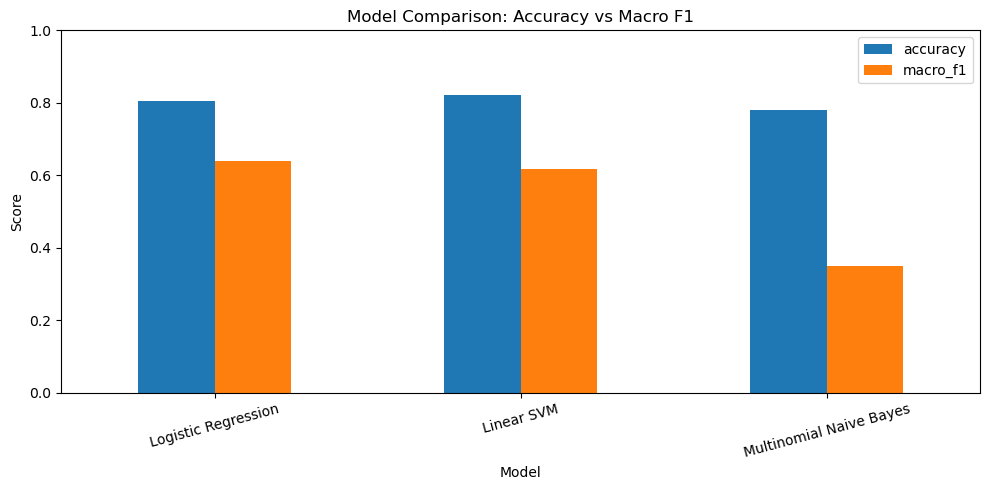

In [10]:
plot_df = results_df.set_index("model")[["accuracy", "macro_f1"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison: Accuracy vs Macro F1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [11]:
comparison_path = OUTPUT_DIR / "model_comparison.csv"
results_df_rounded.to_csv(comparison_path, index=False)

print(f"Saved comparison table to: {comparison_path}")

Saved comparison table to: outputs\reports\model_comparison.csv


## Select the best model

We select the best model by **macro F1**, which is more appropriate than accuracy here because the sentiment classes are imbalanced.

In [12]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_name]

print("Best model:", best_model_name)

Best model: Logistic Regression


## Detailed evaluation for the best model

In [13]:
y_pred_best = best_pipeline.predict(X_test)

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, digits=4))

Best model: Logistic Regression

              precision    recall  f1-score   support

    negative     0.5469    0.6392    0.5895       474
     neutral     0.3608    0.4956    0.4176       565
    positive     0.9568    0.8770    0.9152      3488

    accuracy                         0.8045      4527
   macro avg     0.6215    0.6706    0.6408      4527
weighted avg     0.8395    0.8045    0.8190      4527



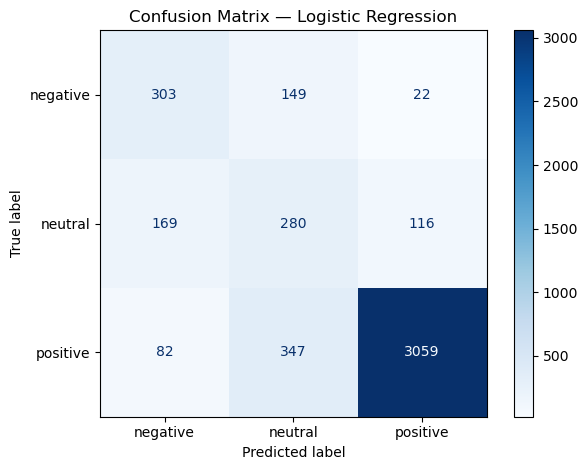

In [14]:
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, y_pred_best, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

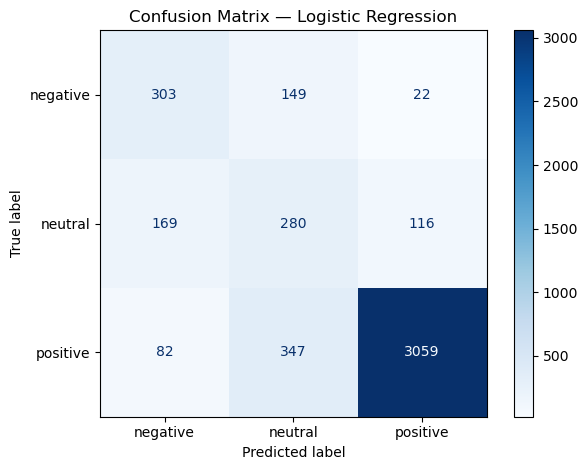

Saved confusion matrix to: outputs\figures\best_model_confusion_matrix.png


In [15]:
cm_fig_path = FIGURE_DIR / "best_model_confusion_matrix.png"

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(cm_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix to: {cm_fig_path}")

## Inspect some example predictions

In [16]:
example_df = pd.DataFrame({
    "review_text": X_test.values,
    "actual_sentiment": y_test.values,
    "predicted_sentiment": y_pred_best
})

example_df["correct"] = example_df["actual_sentiment"] == example_df["predicted_sentiment"]

print("Correct predictions sample:")
example_df[example_df["correct"]].head(10)

Correct predictions sample:


,review_text,actual_sentiment,predicted_sentiment,correct
0,perfect lightweight tee i love love this top i...,positive,positive,True
1,funny armholes in general if you were a fan of...,positive,positive,True
2,beautiful colors are very vibrant lays very ni...,positive,positive,True
3,i so want to love this shirt the print is so s...,neutral,neutral,True
5,fancy and cas at once will be cute in the summ...,positive,positive,True
8,pretty spring flowers i have been eyeing these...,positive,positive,True
10,different but nice this top was different than...,positive,positive,True
11,not what it looks like first of all this is no...,negative,negative,True
12,classy shirt very comfortable shirt washes up ...,positive,positive,True
15,why isn't this dress sold out it is such a pre...,positive,positive,True


In [17]:
print("Misclassified examples sample:")
example_df[~example_df["correct"]].head(15)

Misclassified examples sample:


,review_text,actual_sentiment,predicted_sentiment,correct
4,i was excited to receive this top and wanted t...,neutral,negative,False
6,cute but can add love handles i'm usually a sm...,neutral,positive,False
7,beautiful dress but very small i just received...,positive,neutral,False
9,way too big and bulky the quality of the garme...,negative,neutral,False
13,pretty white pants with nice design at the bot...,positive,neutral,False
14,color transferred to my skin this is a cute to...,negative,neutral,False
18,a little on the short side i purchased this to...,positive,neutral,False
22,white palm color is slightly see through the s...,neutral,positive,False
28,size up i sized up to my higher size choice an...,positive,neutral,False
31,i ordered the teal color it is a beautiful col...,positive,neutral,False


## Save the best pipeline

We save the entire fitted pipeline so the app can load one file and run predictions directly.

In [18]:
pipeline_path = MODEL_DIR / "best_sentiment_pipeline.joblib"
joblib.dump(best_pipeline, pipeline_path)

metadata = {
    "best_model_name": best_model_name,
    "labels": labels,
    "input_column": "clean_review",
    "target_column": "sentiment",
    "selection_metric": "macro_f1"
}

metadata_path = MODEL_DIR / "model_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved pipeline to: {pipeline_path}")
print(f"Saved metadata to: {metadata_path}")

Saved pipeline to: ..\models\best_sentiment_pipeline.joblib
Saved metadata to: ..\models\model_metadata.json


## Try manual sample predictions

In [19]:
sample_reviews = [
    "Absolutely love this dress. Great fit and beautiful fabric.",
    "The material is okay but the sizing feels a bit off.",
    "Very disappointed. Poor quality and not worth the price."
]

sample_preds = best_pipeline.predict(sample_reviews)

pd.DataFrame({
    "sample_review": sample_reviews,
    "predicted_sentiment": sample_preds
})

,sample_review,predicted_sentiment
0,Absolutely love this dress. Great fit and beau...,positive
1,The material is okay but the sizing feels a bi...,neutral
2,Very disappointed. Poor quality and not worth ...,negative


## Notes for the next stage

In the next notebook, we can improve the project with:
- error analysis by department or product class
- investigation of confusing neutral reviews
- common terms in positive vs negative reviews
- review insights for the Streamlit dashboard

After that, the app can use:
- the saved `best_sentiment_pipeline.joblib`
- the cleaned dataset for dashboards and filtering